Customer Behavior Summary:
   user_id  total_orders  total_quantity  total_gmv segment
0  0000e88             2             7.0    9491.60  Medium
1  000159a            21           162.0   84908.69    High
2  000c1b2             1             3.0    5304.84     Low
3  0039abd             1             3.0    2098.24     Low
4  003b0e5             1             9.0    2525.84     Low
Sales Trends Summary:
  order_month    total_gmv  total_orders
0     2022-09  28588980.49          3526
1     2022-10  27677926.44          2682
2     2022-11  31826184.02          3538
3     2023-09  31717114.58          4148
4     2023-10  22833707.32          3124
Top Performing SKUs:
       sku_id   total_gmv  total_quantity  total_orders
1656  aa61eaa  3358729.54          2187.0          1098
1863  bd7c360  3033729.76          1525.0           817
880   5778589  2004186.77          1504.0           847
2     0072cca  1818349.65          1001.0           649
1363  8a9517a  1770669.35          1486.0   

C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


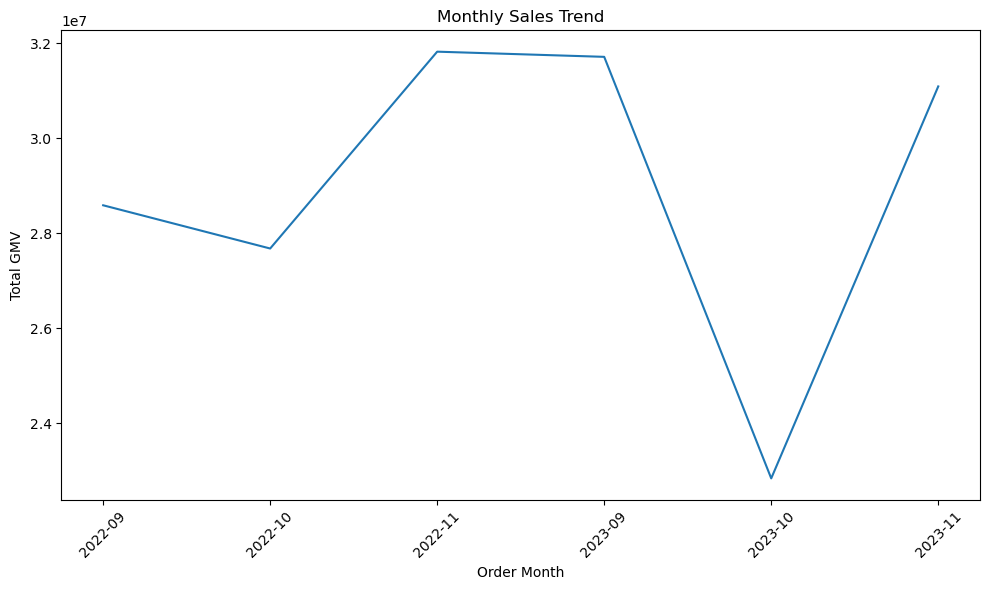

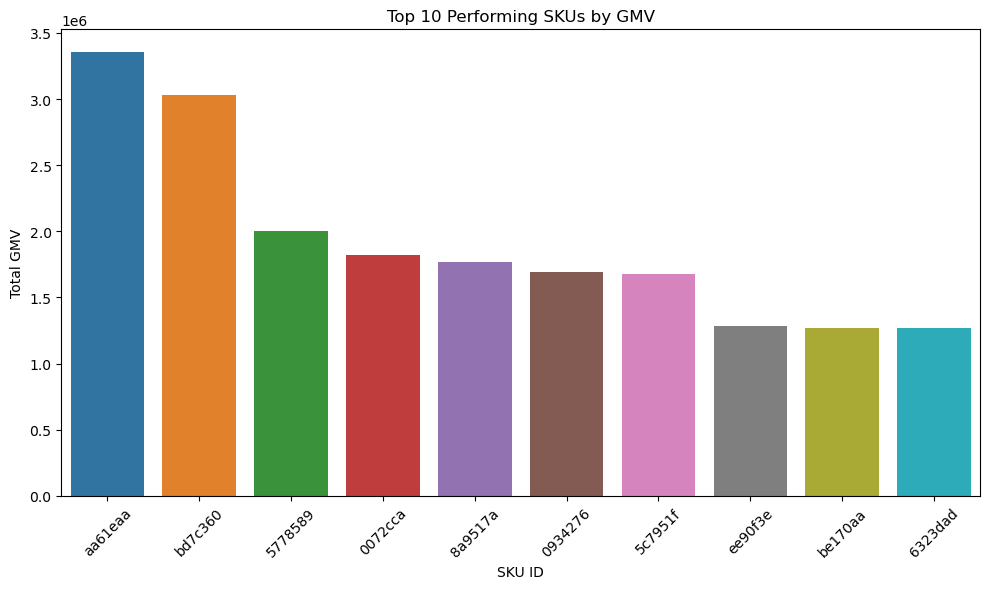

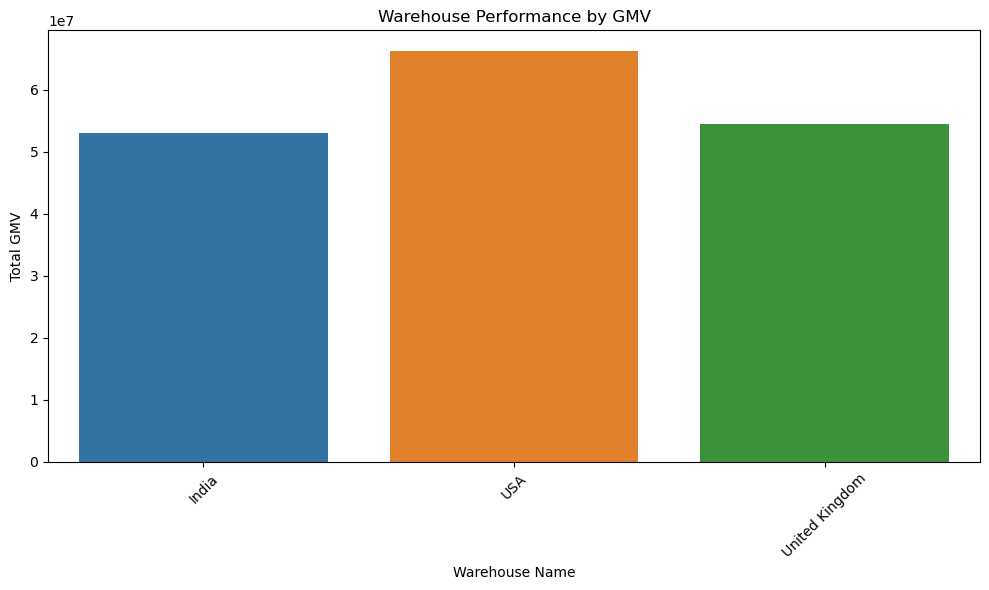

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and Clean Data
data = pd.read_csv('apnaklub_data_2.csv')

# Convert 'order_date' to datetime format
data['order_date'] = pd.to_datetime(data['order_date'], errors='coerce')

# Drop rows with missing values
data.dropna(inplace=True)

# Step 2: Customer Behavior Analysis
customer_behavior = data.groupby('user_id').agg({
    'order_id': 'nunique',  # Number of unique orders
    'quantity': 'sum',      # Total quantity ordered
    'placed_gmv': 'sum'     # Total value of orders placed
}).reset_index()

customer_behavior.columns = ['user_id', 'total_orders', 'total_quantity', 'total_gmv']

# Segment customers into 'Low', 'Medium', 'High' spenders based on GMV
customer_behavior['segment'] = pd.qcut(customer_behavior['total_gmv'], q=3, labels=['Low', 'Medium', 'High'])

print("Customer Behavior Summary:")
print(customer_behavior.head())

# Step 3: Sales Trends Over Time
data['order_month'] = data['order_date'].dt.to_period('M')

# Group by order month to calculate total GMV and number of unique orders
sales_trends = data.groupby('order_month').agg({
    'placed_gmv': 'sum',
    'order_id': 'nunique'
}).reset_index()

sales_trends.columns = ['order_month', 'total_gmv', 'total_orders']

# Convert order_month to string for plotting
sales_trends['order_month'] = sales_trends['order_month'].astype(str)

print("Sales Trends Summary:")
print(sales_trends.head())

# Step 4: SKU Performance
sku_performance = data.groupby('sku_id').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

sku_performance.columns = ['sku_id', 'total_gmv', 'total_quantity', 'total_orders']

# Top and Bottom Performing SKUs
top_skus = sku_performance.sort_values(by='total_gmv', ascending=False).head(10)
bottom_skus = sku_performance.sort_values(by='total_gmv').head(10)

print("Top Performing SKUs:")
print(top_skus)
print("Bottom Performing SKUs:")
print(bottom_skus)

# Step 5: Warehouse Performance
warehouse_performance = data.groupby('warehouse_name').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

warehouse_performance.columns = ['warehouse_name', 'total_gmv', 'total_quantity', 'total_orders']

print("Warehouse Performance Summary:")
print(warehouse_performance.head())

# Step 6: Visualization

# Sales Trends Over Time
plt.figure(figsize=(10, 6))
sns.lineplot(x='order_month', y='total_gmv', data=sales_trends)
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.xlabel('Order Month')
plt.ylabel('Total GMV')
plt.tight_layout()
plt.show()

# Top 10 Performing SKUs by GMV
plt.figure(figsize=(10, 6))
sns.barplot(x='sku_id', y='total_gmv', data=top_skus)
plt.title('Top 10 Performing SKUs by GMV')
plt.xlabel('SKU ID')
plt.ylabel('Total GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Warehouse Performance by GMV
plt.figure(figsize=(10, 6))
sns.barplot(x='warehouse_name', y='total_gmv', data=warehouse_performance)
plt.title('Warehouse Performance by GMV')
plt.xlabel('Warehouse Name')
plt.ylabel('Total GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
